In [ ]:
###
    # This code plot the seasonal sensivity of soil temperature simulated by moisture-driven model (when supercooled soil water is disabled) and CMIP6 models.
    # 1. The moisture-driven sensitivities are calculated from "../Process/10 **.py", and saved in "../Data/Moisture_driven/".
    # 2. The CMIP6 sensitivities are calculated using "05_Ts_sensitivity.py", and saved in "../Data/Ts_seasonal_sensitivity/".
    # 3. Read the sensitivities, then generates scatter plots comparing moisture-driven sensitivities against CMIP6 sensitivity;
    # Output: Figure S12.
###

In [2]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

In [3]:
def area_weight_mean(data2D, lat, lon):
    """
    Calculate the area-weighted mean of 2D data, taking into account grid cell areas.
    
    Parameters:
    data2D: ndarray
        Variable for area-weighted averaging, with shape [lat, lon].
    lat: ndarray
        Latitude array, 1D, in degrees.
    lon: ndarray
        Longitude array, 1D, in degrees.
    
    Returns:
    float
        Area-weighted mean of the data.
    """
    # Convert latitude to radians
    rad = np.pi / 180.0
    lat_rad = lat * rad

    # Calculate latitude and longitude resolution
    re = 6371220.0  # Earth radius (in meters)
    dlon = np.abs(lon[1] - lon[0]) * rad  # Longitude resolution (in radians)
    dlat = np.abs(lat[1] - lat[0]) * rad  # Latitude resolution (in radians)

    # Calculate the area of each grid cell
    sin_lat1 = np.sin(lat_rad + dlat / 2)
    sin_lat2 = np.sin(lat_rad - dlat / 2)
    grid_areas = (re ** 2) * dlon * (sin_lat1 - sin_lat2)[:, np.newaxis]  # (lat, lon)

    # Calculate weighted mean
    valid_mask = ~np.isnan(data2D)  # Valid data mask
    weighted_sum = np.nansum(data2D * grid_areas * valid_mask)  # Sum of weighted values
    total_weight = np.nansum(grid_areas * valid_mask)  # Sum of weights

    # If total weight is 0 (all NaN), return NaN
    if total_weight == 0:
        return np.nan

    return weighted_sum / total_weight

In [ ]:
depths = ['1.6m', '2.4m', '3.2m']
models = ["CESM2","CESM2-FV2","CESM2-WACCM",
          "CNRM-CM6-1","CNRM-ESM2-1",
          "GFDL-ESM4","NorESM2-LM",
          "NorESM2-MM","TaiESM1"
          ]
CMIP6_amplitude_ratio = pd.DataFrame(index=depths, columns=models)
for j,depth in enumerate([1.6,2.4,3.2]):
    # Load the permafrost probability data for the given depth
    q = xr.open_dataset('../Data/probability_lt_threshold_'+str(int(depth*100))+'.nc')
    per_extent = q['probability_lt_threshold'][:,:360] # longitude limited to 0-180° Eurasian continent portion
    for i in range(len(models)):
        modelname = models[i]
        Ts_file = '../Data/Ts_seasonal_sensitivity/Simulated_grid_sensitivity/'+str(int(depth*100))+'/' + modelname + '_tsl_seasonalcycle_avg.nc'
        g = xr.open_dataset(Ts_file)
        tsl_seasonalcycle_avg2 = g['tsl_seasonalcycle_avg']
        lat = g["lat"]
        lon = g["lon"]

        # Seasonal-scale soil temperature sensitivity masked by per_extent probability
        tsl_seasonalcycle_avg2 = xr.where(per_extent==0, np.nan, tsl_seasonalcycle_avg2)
        tsl_seasonalcycle_avg2 = xr.where(per_extent==1, np.nan, tsl_seasonalcycle_avg2)
        CMIP6_amplitude_ratio[modelname][depths[j]] = area_weight_mean(tsl_seasonalcycle_avg2, lat.data, lon.data)
CMIP6_amplitude_ratio

,CESM2,CESM2-FV2,CESM2-WACCM,CNRM-CM6-1,CNRM-ESM2-1,GFDL-ESM4,NorESM2-LM,NorESM2-MM,TaiESM1
1.6m,0.502997,0.519459,0.514431,0.389581,0.37453,0.35899,0.484341,0.527313,0.383332
2.4m,0.386471,0.393438,0.393872,0.254832,0.236882,0.258903,0.367329,0.402671,0.280637
3.2m,0.302768,0.305014,0.308403,0.178587,0.164538,0.195684,0.284069,0.314444,0.224049


In [5]:
amplitude_ratio_offsup = pd.read_csv("../Data/Moisture_driven/Ts_seasonal_sensitivity_offsup.csv")
amplitude_ratio_offsup = amplitude_ratio_offsup.iloc[:,1:]
amplitude_ratio_offsup

,CESM2,CESM2-FV2,CESM2-WACCM,CNRM-CM6-1,CNRM-ESM2-1,GFDL-ESM4,NorESM2-LM,NorESM2-MM,TaiESM1
0,0.421084,0.444530,0.440481,0.353528,0.318311,0.358992,0.421284,0.456308,0.326506
1,0.307849,0.317328,0.320081,0.234635,0.210181,0.254722,0.284552,0.330487,0.228287
2,0.228707,0.235194,0.239070,0.169481,0.152063,0.192343,0.193988,0.247504,0.161677


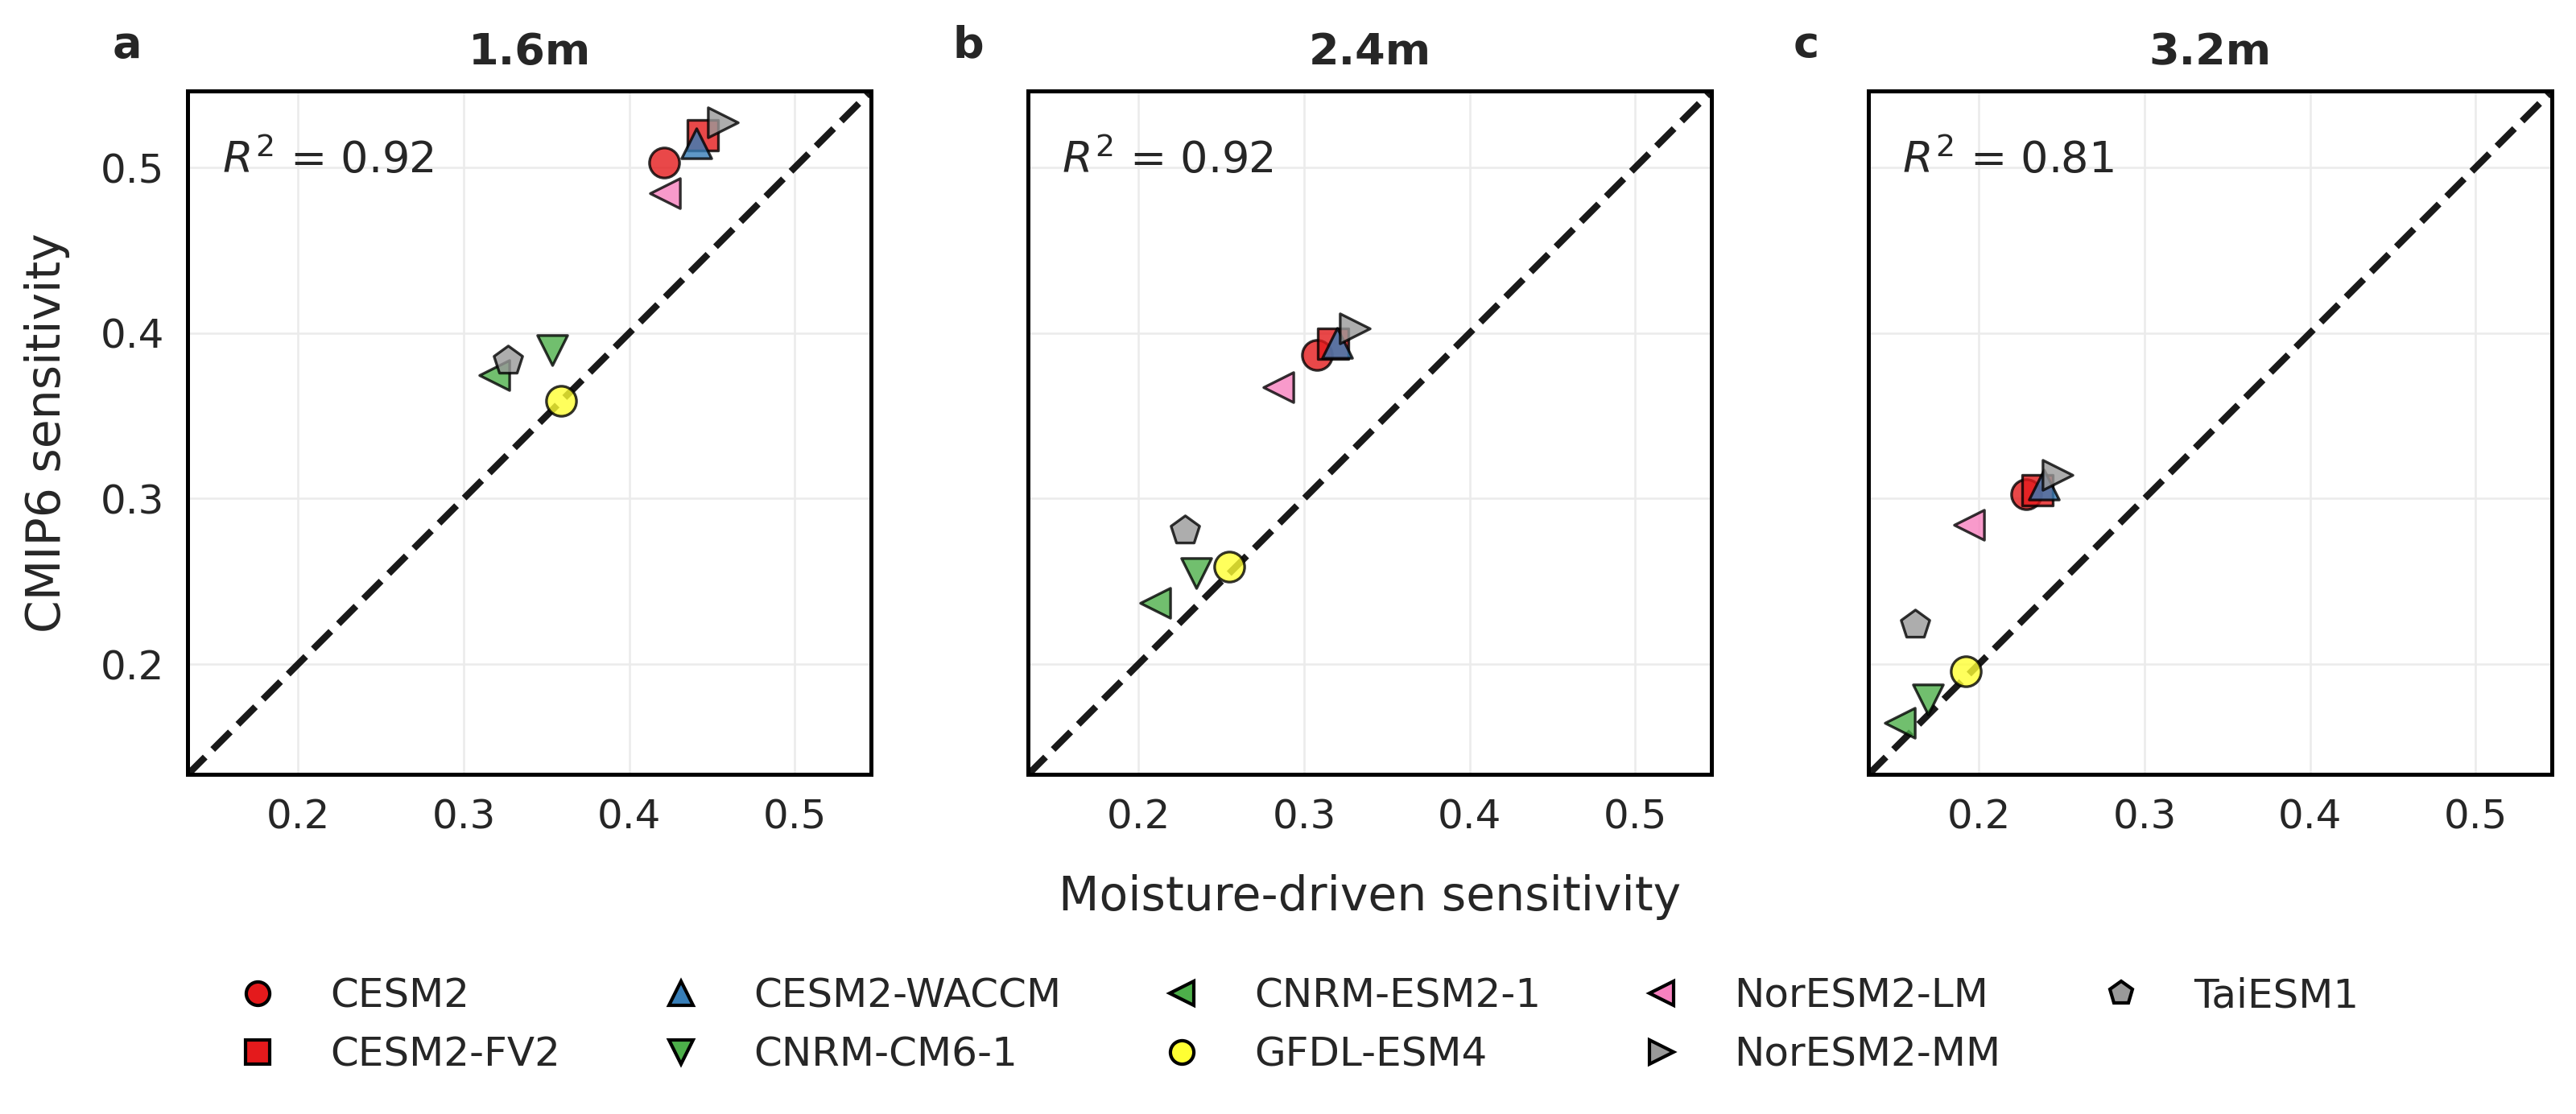

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.lines import Line2D

# -----------------------------
# model list
# -----------------------------

models = [
    "CESM2",
    "CESM2-FV2",
    "CESM2-WACCM",
    "CNRM-CM6-1",
    "CNRM-ESM2-1",
    "GFDL-ESM4",
    "NorESM2-LM",
    "NorESM2-MM",
    "TaiESM1"
]

depths = ["1.6m","2.4m","3.2m"]

# -----------------------------
# plot style
# -----------------------------

plt.rcParams.update({
    "font.size":12,
    "axes.labelsize":14,
    "axes.titlesize":13,
    "axes.linewidth":1.2,
    "xtick.labelsize":12,
    "ytick.labelsize":12
})

models_all = ["CESM2", "CESM2-FV2", "CESM2-WACCM", "CNRM-CM6-1-HR", "CNRM-CM6-1", "CNRM-ESM2-1",
             "E3SM-1-1", "FGOALS-f3-L", "FGOALS-g3", "GFDL-CM4", "GFDL-ESM4", "MIROC6",
             "MIROC-ES2L", "MPI-ESM1-2-HR", "MPI-ESM1-2-LR", "NorESM2-LM", "NorESM2-MM", "TaiESM1"]

# Markers and colors for all models
markers_all = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'X']
colors_all = plt.cm.Set1(np.linspace(0, 1, len(models_all)))

# Create a mapping dictionary from model to fixed marker and color
model_style = {}
for i, model in enumerate(models_all):
    model_style[model] = {
        'marker': markers_all[i % len(markers_all)],
        'color': colors_all[i]
    }

# Assign colors and markers to current models based on the mapping dictionary
markers = [model_style[model]['marker'] for model in models]
colors = [model_style[model]['color'] for model in models]

# -----------------------------
# reshape data
# -----------------------------

data_list=[]

for i,depth in enumerate(depths):
    for model in models:

        data_list.append({
            "Depth":depth,
            "Model":model,
            "Moisture":amplitude_ratio_offsup.loc[i,model],
            "CMIP6":CMIP6_amplitude_ratio.loc[depth,model]
        })

plot_data=pd.DataFrame(data_list)

# -----------------------------
# axis range
# -----------------------------

x_all=plot_data["Moisture"].values
y_all=plot_data["CMIP6"].values

data_min=min(x_all.min(),y_all.min())
data_max=max(x_all.max(),y_all.max())

margin=(data_max-data_min)*0.05
plot_range=[data_min-margin,data_max+margin]

# -----------------------------
# create figure
# -----------------------------

fig,axes=plt.subplots(1,3,figsize=(11,4),sharex=True,sharey=True,dpi=300)

fig.subplots_adjust(wspace=0.08)

# -----------------------------
# plotting
# -----------------------------

for idx,(ax,depth) in enumerate(zip(axes,depths)):

    depth_data=plot_data[plot_data["Depth"]==depth]

    for i,(_,row) in enumerate(depth_data.iterrows()):

        model=row["Model"]

        color=colors[i]
        lw=0.8

        ax.scatter(
            row["Moisture"],
            row["CMIP6"],
            marker=markers[i],
            s=80,
            color=color,
            edgecolor="black",
            linewidth=lw,
            alpha=0.8,
            label=model if idx==0 else "",
            zorder=3
        )

    # 1:1 line
    ax.plot(
        plot_range,
        plot_range,
        color="black",
        linestyle="--",
        linewidth=2,
        alpha=0.9,
        zorder=1
    )

    # statistics
    x=depth_data["Moisture"].values
    y=depth_data["CMIP6"].values

    r,p=stats.pearsonr(x,y)
    r2=r**2

    ax.text(
        0.05,
        0.93,
        f"$R^2$ = {r2:.2f}",
        transform=ax.transAxes,
        fontsize=13,
        ha="left",
        va="top"
    )

    # panel label
    ax.text(
        -0.11,
        1.05,
        f"{chr(97+idx)}",
        transform=ax.transAxes,
        fontsize=13,
        fontweight="bold"
    )

    # title
    ax.set_title(depth, fontweight='bold', pad=8)

    # axes
    ax.set_xlim(plot_range)
    ax.set_ylim(plot_range)

    ax.set_aspect("equal")

    ax.grid(True,linewidth=0.6,color="0.92")

    if idx==0:
        ax.set_ylabel("CMIP6 sensitivity", labelpad=9)

    if idx==1:
        ax.set_xlabel("Moisture-driven sensitivity", labelpad=11)

# -----------------------------
# legend (models)
# -----------------------------

legend_elements=[]

for i,model in enumerate(models):

    color=colors[i]

    legend_elements.append(
        Line2D(
            [0],[0],
            marker=markers[i],
            linestyle="None",
            markerfacecolor=color,
            markeredgecolor="black",
            markersize=7,
            label=model
        )
    )

fig.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5,-0.12),
    ncol=5,
    frameon=False
)

plt.tight_layout(rect=[0,0.08,1,1])

plt.show()

In [ ]:
fig.savefig("../Figures/FigureS12.png", bbox_inches='tight',dpi=300)